# Treino do YOLOv8n custom (Sprint 6)

Gera os pesos `models/yolov8n_surgical.pt` consumidos por `src/video/detector.py`. Roda no Google Colab com GPU T4 gratuita. Pipeline auto-contido: baixa CholecSeg8k do Hugging Face, converte mascaras em bounding boxes, treina o YOLOv8n e exporta os artefatos. Idempotente: se o dataset ja existir na pasta configurada, pula direto para o treino.

Contexto da escolha do dataset e do alvo do detector em [docs/arquitetura/decisoes_tecnicas.md](../docs/arquitetura/decisoes_tecnicas.md) (ADR-012).

## 1. Setup

Esta secao prepara o ambiente em 3 partes:

**1.1 GPU + batch:** detecta automaticamente o GPU disponivel via `nvidia-smi` e seleciona o batch/workers apropriado. Suporta T4 (gratuita, 15 GB VRAM), L4 (Colab Pro, 22-24 GB, ~2.5x mais rapido) e A100 (Colab Pro+, 40 GB, ~5x mais rapido).

| GPU | VRAM | Batch padrao | Workers | Velocidade relativa |
|-----|------|--------------|---------|---------------------|
| T4 | 15 GB | 96 | 8 | 1x (baseline) |
| L4 | 22-24 GB | 160 | 12 | ~2.5-3x |
| A100 | 40 GB | 320 | 16 | ~5x |

Para mudar a GPU: `Runtime > Change runtime type > GPU type`. A celula detecta a nova GPU automaticamente.

**1.2 Drive:** usado apenas para artefatos pequenos e criticos que valem persistir entre sessoes:
- `yolo_runs/<run_name>/weights/`: `best.pt` e `last.pt` (~6-12 MB cada)
- `yolo_runs/<run_name>/`: graficos (`results.png`, `confusion_matrix.png`), CSV (`results.csv`)

**Dataset (raw zip 3 GB + convertido 2.7 GB) NAO e cacheado no Drive** porque ler do Drive provou-se mais lento do que re-baixar direto do Hugging Face. Em cada nova sessao do Colab o dataset e baixado e convertido localmente em `/content/`.

Em re-execucao com a mesma sessao do Colab ativa, o local (`/content/`) ja tem o dataset e o treino pula direto pro fine-tuning. Se o Colab desconectar, o `last.pt` salvo no Drive permite resumir o treino (callback `on_train_epoch_end` sincroniza pesos por epoca)

In [1]:
# 1.1 GPU + batch (auto-detect via nvidia-smi)
# A escolha do tipo de GPU e manual no Colab: Runtime > Change runtime type.
# Esta celula apenas detecta qual GPU foi alocada e ajusta batch/workers.
import subprocess

GPU_CONFIGS = {
    'T4': {'batch': 96, 'workers': 8, 'vram_gb': 15, 'note': 'gratuito'},
    'L4': {'batch': 160, 'workers': 12, 'vram_gb': 22, 'note': 'Colab Pro, ~2.5x mais rapido que T4'},
    'A100': {'batch': 320, 'workers': 16, 'vram_gb': 40, 'note': 'Colab Pro+, ~5x mais rapido que T4'},
}

def _detect_gpu():
    """Roda nvidia-smi e retorna a chave de GPU_CONFIGS, ou None."""
    try:
        out = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
            text=True, timeout=10,
        ).strip()
    except Exception as exc:
        print(f'[gpu] Falha ao rodar nvidia-smi: {exc}')
        return None, None

    first = out.split('\n')[0]
    upper = first.upper()
    for key in ('A100', 'L4', 'T4'):
        if key in upper:
            return key, first
    return None, first

# Override manual: descomente pra forcar (ex: testar limites)
# GPU_TYPE = 'T4'

_detected, _raw_name = _detect_gpu()
if 'GPU_TYPE' not in dir() or GPU_TYPE is None:
    GPU_TYPE = _detected or 'T4'

cfg = GPU_CONFIGS[GPU_TYPE]
BATCH_SIZE = cfg['batch']
WORKERS = cfg['workers']

print(f'[gpu] nvidia-smi reportou: {_raw_name!r}')
print(f'[gpu] Mapeado para: {GPU_TYPE} ({cfg["vram_gb"]} GB VRAM, {cfg["note"]})')
print(f'[gpu] Batch size: {BATCH_SIZE}, workers: {WORKERS}')
if _detected is None and _raw_name:
    print(f'[gpu] AVISO: GPU nao mapeada explicitamente em GPU_CONFIGS, usando fallback T4.')
    print(f'[gpu] Pra usar mais VRAM, descomentar `GPU_TYPE = ...` acima.')

print()
!nvidia-smi
!pip install -q ultralytics==8.3.30 huggingface_hub

# 1.2 Drive (so para artefatos pequenos do treino: best.pt, last.pt, graficos)
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
from pathlib import Path

DRIVE_ROOT = Path('/content/drive/MyDrive/medica-ia')
DRIVE_RUNS = DRIVE_ROOT / 'yolo_runs'
DRIVE_RUNS.mkdir(parents=True, exist_ok=True)

# Paths locais no Colab (dataset bruto e convertido NAO sincronizam pro Drive:
# o read do Drive provou-se mais lento que re-baixar do HF a cada sessao)
DATASET_DIR = '/content/cholecseg8k_yolo'
RAW_DIR = '/content/cholecseg8k_raw'
RUNS_DIR = '/content/runs/detect'
RUN_NAME = 'surgical_instruments'
DATA_YAML = f'{DATASET_DIR}/data.yaml'

print()
print(f'Drive root:           {DRIVE_ROOT}')
print(f'  runs (output):      {DRIVE_RUNS}')
print(f'Working dir (Colab):  {DATASET_DIR} (efemero, nao sincroniza pro Drive)')


[gpu] nvidia-smi reportou: 'NVIDIA A100-SXM4-40GB'
[gpu] Mapeado para: A100 (40 GB VRAM, Colab Pro+, ~5x mais rapido que T4)
[gpu] Batch size: 320, workers: 16

Sat May 16 19:58:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             45W /  400W |       0MiB /  40960MiB |   

## 2. Dataset

Pipeline em 3 passos: verifica cache + baixa, extrai + converte mascaras em bboxes, gera `data.yaml`. Tudo idempotente.

### 2.1 Cache + download

Pipeline de cache em 2 niveis: primeiro verifica se o dataset convertido ja esta no working dir do Colab; se nao, verifica no Drive (cache persistente). Se em nenhum dos dois, baixa do HF (e salva o zip no Drive para futuras sessoes).

In [2]:
def split_is_complete(base_dir, split, min_count):
    """Conta arquivos em <base_dir>/images/<split>, tolerante a erros de FS."""
    img_dir = Path(base_dir) / 'images' / split
    try:
        if not img_dir.is_dir():
            return False
        n = sum(1 for _ in img_dir.iterdir())
        return n >= min_count
    except OSError as exc:
        print(f'[cache] aviso: erro ao ler {img_dir}: {exc}')
        return False

EXPECTED = {'train': 5000, 'val': 1500, 'test': 700}

# Verifica se o dataset convertido ja esta local (sessao Colab ainda viva).
local_ready = all(split_is_complete(DATASET_DIR, s, n) for s, n in EXPECTED.items())

if local_ready:
    NEEDS_PREPARE = False
    print(f'[cache] OK: dataset ja no Colab em {DATASET_DIR}')
else:
    NEEDS_PREPARE = True
    print('[cache] Dataset nao encontrado no Colab. Vou baixar do HF.')
    print('[cache] (Drive nao cacheia dataset: read do Drive eh mais lento que HF.)')

    from huggingface_hub import snapshot_download
    snapshot_download(
        repo_id='minwoosun/CholecSeg8k',
        repo_type='dataset',
        local_dir=RAW_DIR,
        allow_patterns=['data/CholecSeg8k.zip'],
    )

    !ls -lh {RAW_DIR}/data/CholecSeg8k.zip


[cache] Dataset nao encontrado no Colab. Vou baixar do HF.
[cache] (Drive nao cacheia dataset: read do Drive eh mais lento que HF.)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

-rw-r--r-- 1 root root 2.9G May 16 19:58 /content/cholecseg8k_raw/data/CholecSeg8k.zip


### 2.2 Extracao do zip

Descompacta `CholecSeg8k.zip` (~3 GB) em `RAW_DIR/extracted/`. Usa `zipfile` + `tqdm` para mostrar progresso por arquivo. Tempo esperado no Colab: 3-8 minutos.

In [3]:
if NEEDS_PREPARE:
    import zipfile
    from pathlib import Path
    from tqdm.auto import tqdm

    zip_path = Path(RAW_DIR) / 'data' / 'CholecSeg8k.zip'
    extracted_root = Path(RAW_DIR) / 'extracted'

    if not extracted_root.exists() or not any(extracted_root.iterdir()):
        extracted_root.mkdir(parents=True, exist_ok=True)
        print(f'Extraindo {zip_path} -> {extracted_root}')
        with zipfile.ZipFile(zip_path) as zf:
            members = zf.namelist()
            for member in tqdm(members, desc='Extraindo', unit='arq'):
                zf.extract(member, extracted_root)
        print(f'Extracao concluida: {len(members)} arquivos em {extracted_root}.')
    else:
        print(f'Zip ja extraido em {extracted_root}, pulando.')
else:
    print('Pulado (cache).')


Extraindo /content/cholecseg8k_raw/data/CholecSeg8k.zip -> /content/cholecseg8k_raw/extracted


Extraindo:   0%|          | 0/32439 [00:00<?, ?arq/s]

Extracao concluida: 32439 arquivos em /content/cholecseg8k_raw/extracted.


### 2.3 Conversao mask -> bbox YOLO

Indexa os pares (frame, mascara) extraidos, faz split estratificado 70/20/10 com seed fixa (42), e converte cada mascara grayscale em bounding boxes YOLO. **3 classes alvo:**
- `grasper` (pixel 31) - pinca atraumatica laparoscopica
- `l_hook_electrocautery` (pixel 32) - gancho eletrocauterizador
- `blood` (pixel 24) - sangramento durante o procedimento

Bboxes menores que 100 px sao descartadas. A classe `blood` foi adicionada como sinal de complicacao cirurgica (alinhada com 'Sinais de complicacoes em cirurgias ginecologicas' do enunciado), nao apenas como descricao de instrumental.

In [4]:
if NEEDS_PREPARE:
    import shutil
    from pathlib import Path
    import cv2
    import numpy as np
    from tqdm.auto import tqdm

    extracted_root = Path(RAW_DIR) / 'extracted'

    INSTRUMENT_CLASSES = {'grasper': 0, 'l_hook_electrocautery': 1, 'blood': 2}
    CLASS_PIXEL_VALUE = {'grasper': 31, 'l_hook_electrocautery': 32, 'blood': 24}
    SPLIT_RATIO = (0.7, 0.2, 0.1)
    SEED = 42
    MIN_BBOX_AREA_PX = 100

    def mask_to_bboxes_by_class(mask_path):
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return {}
        bboxes = {}
        for class_name, pixel_val in CLASS_PIXEL_VALUE.items():
            ys, xs = np.where(mask == pixel_val)
            if len(xs) == 0:
                continue
            x_min, x_max = int(xs.min()), int(xs.max())
            y_min, y_max = int(ys.min()), int(ys.max())
            w, h = x_max - x_min, y_max - y_min
            if w * h < MIN_BBOX_AREA_PX:
                continue
            bboxes[class_name] = (x_min, y_min, w, h)
        return bboxes

    def yolo_format(bbox, img_w, img_h, class_id):
        x, y, w, h = bbox
        cx = (x + w / 2) / img_w
        cy = (y + h / 2) / img_h
        return f'{class_id} {cx:.6f} {cy:.6f} {w / img_w:.6f} {h / img_h:.6f}\n'

    out = Path(DATASET_DIR)
    for split in ('train', 'val', 'test'):
        (out / 'images' / split).mkdir(parents=True, exist_ok=True)
        (out / 'labels' / split).mkdir(parents=True, exist_ok=True)

    print('Indexando pares (frame, mask)...')
    items = []
    for img_path in tqdm(sorted(extracted_root.rglob('frame_*_endo.png')), desc='Indexando', unit='arq'):
        if any(s in img_path.name for s in ('color_mask', 'watershed_mask')):
            continue
        ann_path = img_path.with_name(img_path.name.replace('_endo.png', '_endo_mask.png'))
        if ann_path.exists():
            items.append((img_path, ann_path))

    if not items:
        raise RuntimeError(
            f'Nenhum par (frame, mask) encontrado em {extracted_root}. '
            f'Conferir layout do zip extraido (esperado: subpastas video_XX/video_XX_YY/ com frame_*_endo.png e frame_*_endo_mask.png).'
        )

    print(f'Pares encontrados: {len(items)}')

    rng = np.random.default_rng(seed=SEED)
    indices = list(range(len(items)))
    rng.shuffle(indices)
    n = len(items)
    n_train = int(n * SPLIT_RATIO[0])
    n_val = int(n * SPLIT_RATIO[1])
    splits = {
        'train': indices[:n_train],
        'val': indices[n_train:n_train + n_val],
        'test': indices[n_train + n_val:],
    }

    cls_count = {cid: 0 for cid in INSTRUMENT_CLASSES.values()}
    for split_name, idxs in splits.items():
        for i in tqdm(idxs, desc=f'Convertendo {split_name}', unit='frame'):
            img_path, ann_path = items[i]
            unique_name = f'{img_path.parent.name}_{img_path.name}'
            unique_stem = f'{img_path.parent.name}_{img_path.stem}'
            shutil.copy(img_path, out / 'images' / split_name / unique_name)
            dst_lbl = out / 'labels' / split_name / f'{unique_stem}.txt'

            img = cv2.imread(str(img_path))
            if img is None:
                dst_lbl.touch()
                continue
            h, w = img.shape[:2]

            bboxes = mask_to_bboxes_by_class(ann_path)
            lines = []
            for class_name, bbox in bboxes.items():
                cid = INSTRUMENT_CLASSES[class_name]
                lines.append(yolo_format(bbox, w, h, cid))
                cls_count[cid] += 1
            dst_lbl.write_text(''.join(lines) if lines else '')

    print(f'\nResumo: {n} frames processados')
    for name, cid in sorted(INSTRUMENT_CLASSES.items(), key=lambda kv: kv[1]):
        print(f'  {name} (id {cid}): {cls_count[cid]} bboxes')
    print(f"Splits: train={len(splits['train'])} val={len(splits['val'])} test={len(splits['test'])}")

else:
    print('Pulado (cache).')


Indexando pares (frame, mask)...


Indexando:   0%|          | 0/8080 [00:00<?, ?arq/s]

Pares encontrados: 8080


Convertendo train:   0%|          | 0/5656 [00:00<?, ?frame/s]

Convertendo val:   0%|          | 0/1616 [00:00<?, ?frame/s]

Convertendo test:   0%|          | 0/808 [00:00<?, ?frame/s]


Resumo: 8080 frames processados
  grasper (id 0): 6020 bboxes
  l_hook_electrocautery (id 1): 2251 bboxes
  blood (id 2): 690 bboxes
Splits: train=5656 val=1616 test=808


### 2.4 data.yaml

Aponta para a raiz do dataset no Colab (sobrescreve o path relativo do repo local).

In [5]:
import yaml

with open(DATA_YAML, 'w') as f:
    yaml.safe_dump({
        'path': DATASET_DIR,
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'nc': 3,
        'names': {0: 'grasper', 1: 'l_hook_electrocautery', 2: 'blood'},
    }, f, sort_keys=False)

print(open(DATA_YAML).read())


path: /content/cholecseg8k_yolo
train: images/train
val: images/val
test: images/test
nc: 3
names:
  0: grasper
  1: l_hook_electrocautery
  2: blood



### 2.5 Validacao + visualizacao

Sanity check: contagem por split e quatro amostras com bbox sobre o frame.

In [6]:
for split in ['train', 'val', 'test']:
    img_dir = os.path.join(DATASET_DIR, 'images', split)
    lbl_dir = os.path.join(DATASET_DIR, 'labels', split)
    n_imgs = len(os.listdir(img_dir))
    n_nonempty = sum(1 for f in os.listdir(lbl_dir) if os.path.getsize(os.path.join(lbl_dir, f)) > 0)
    print(f'{split:>5}: {n_imgs:>5} imagens ({n_nonempty} com bbox)')


train:  5656 imagens (4516 com bbox)
  val:  1616 imagens (1269 com bbox)
 test:   808 imagens (654 com bbox)


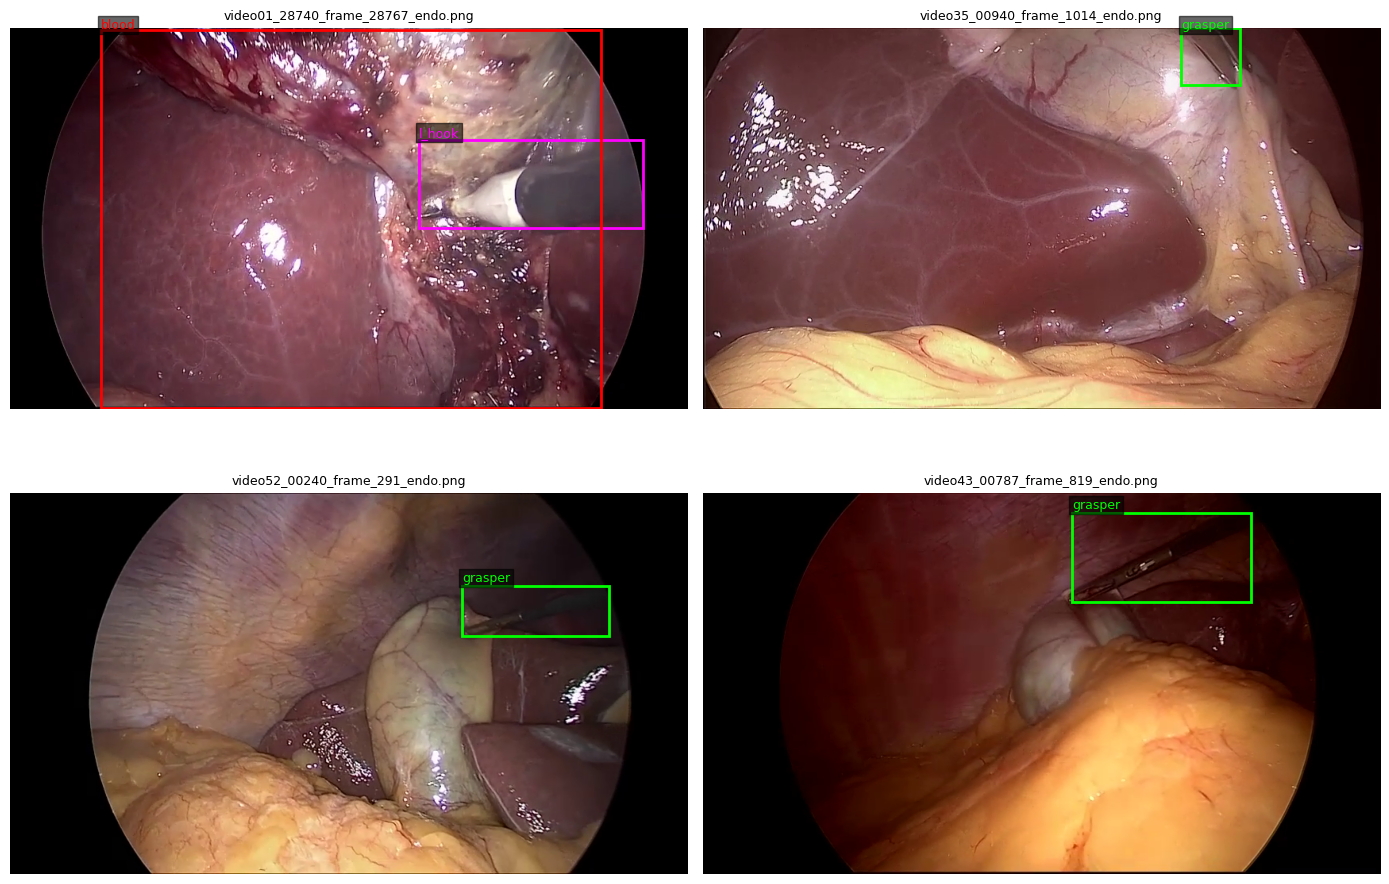

In [7]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

random.seed(42)

CLASS_COLORS = {0: 'lime', 1: 'magenta', 2: 'red'}
CLASS_LABELS = {0: 'grasper', 1: 'l_hook', 2: 'blood'}

img_dir = os.path.join(DATASET_DIR, 'images', 'train')
lbl_dir = os.path.join(DATASET_DIR, 'labels', 'train')

candidates = [f for f in os.listdir(img_dir)
              if os.path.getsize(os.path.join(lbl_dir, f.replace('.png', '.txt'))) > 0]

if not candidates:
    raise RuntimeError(
        f'Nenhuma imagem com bbox em {lbl_dir}. '
        'A conversao da 2.2 nao gerou labels (ou o cache em DATASET_DIR ficou inconsistente). '
        'Apague DATASET_DIR e rode tudo de novo a partir da 2.1.'
    )

samples = random.sample(candidates, min(4, len(candidates)))
n = len(samples)
rows = (n + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(14, 5 * rows))
axes_list = list(axes.flat) if n > 1 else [axes]

for ax, name in zip(axes_list, samples):
    img = Image.open(os.path.join(img_dir, name))
    W, H = img.size
    ax.imshow(img)
    ax.set_title(name, fontsize=9)
    ax.axis('off')

    with open(os.path.join(lbl_dir, name.replace('.png', '.txt'))) as f:
        for line in f:
            parts = line.strip().split()
            cls = int(parts[0])
            xc, yc, w, h = map(float, parts[1:5])
            x0 = (xc - w / 2) * W
            y0 = (yc - h / 2) * H
            ax.add_patch(patches.Rectangle(
                (x0, y0), w * W, h * H,
                linewidth=2, edgecolor=CLASS_COLORS.get(cls, 'cyan'), facecolor='none',
            ))
            ax.text(x0, max(0, y0 - 5), CLASS_LABELS.get(cls, str(cls)),
                    color=CLASS_COLORS.get(cls, 'cyan'), fontsize=9,
                    bbox=dict(facecolor='black', alpha=0.6, pad=2))

for ax in axes_list[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


## 3. Treino

Treino na GPU configurada na celula 1.1 (`device=0` no `model.train()`). Partimos dos pesos `yolov8n.pt` (pre-treinado em COCO) e fazemos fine-tuning nas **3 classes alvo** (grasper, l_hook_electrocautery, blood). Escolhemos a variante **nano** porque o app Gradio do projeto roda os pesos finais em CPU local (sem GPU dedicada), entao a inferencia precisa ser leve. O treino em si nao tem essa restricao: usa a GPU do Colab.

`BATCH_SIZE` e `WORKERS` vem das constantes definidas em 1.1 (96/8 para T4, 160/12 para L4). Os valores foram calibrados para usar ~70-80% da VRAM disponivel sem risco de OOM.

**Resilencia a desconexao do Colab:**
- Callback `on_train_epoch_end` copia `last.pt` e `best.pt` pro Drive ao fim de cada epoch
- Se a sessao cair, ao re-abrir o notebook o codigo detecta o checkpoint no Drive e oferece resumir via `resume=True`
- Sync final completo (graficos, csv, weights) ao terminar o treino

In [8]:
from ultralytics import YOLO

# Detectar checkpoint anterior no Drive (caso sessao tenha caido)
drive_last = DRIVE_RUNS / RUN_NAME / 'weights' / 'last.pt'
local_run_dir = Path(RUNS_DIR) / RUN_NAME

resume_flag = False
if drive_last.exists() and not (local_run_dir / 'weights' / 'last.pt').exists():
    size_mb = drive_last.stat().st_size / 1e6
    print(f'Checkpoint anterior no Drive ({size_mb:.1f} MB): {drive_last}')
    print('Copiando run dir do Drive para Colab e resumindo...')
    shutil.copytree(DRIVE_RUNS / RUN_NAME, local_run_dir, dirs_exist_ok=True)
    model = YOLO(str(local_run_dir / 'weights' / 'last.pt'))
    resume_flag = True
else:
    model = YOLO('yolov8n.pt')

# Callback: ao fim de cada epoch, copiar weights/last.pt e weights/best.pt pro Drive
def _sync_weights_to_drive(trainer):
    save_dir = Path(trainer.save_dir)
    dst_weights = DRIVE_RUNS / RUN_NAME / 'weights'
    dst_weights.mkdir(parents=True, exist_ok=True)
    for wname in ('last.pt', 'best.pt'):
        src = save_dir / 'weights' / wname
        if src.exists():
            shutil.copy(src, dst_weights / wname)

model.add_callback('on_train_epoch_end', _sync_weights_to_drive)

# Treinar (ou resumir)
if resume_flag:
    results = model.train(resume=True)
else:
    results = model.train(
        data=DATA_YAML,
        epochs=40,
        imgsz=640,
        batch=BATCH_SIZE,
        workers=WORKERS,
        device=0,
        name=RUN_NAME,
        patience=10,
        project=RUNS_DIR,
        exist_ok=True,
        verbose=True,
    )

# Sync final completo (graficos, csv, etc) pro Drive
print('\nSincronizando run dir completo com o Drive...')
dst = DRIVE_RUNS / RUN_NAME
if dst.exists():
    shutil.rmtree(dst)
shutil.copytree(local_run_dir, dst)
print(f'OK: {dst}')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 60.9MB/s]


New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/cholecseg8k_yolo/data.yaml, epochs=40, time=None, patience=10, batch=320, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=16, project=/content/runs/detect, name=surgical_instruments, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retin

100%|██████████| 755k/755k [00:00<00:00, 16.0MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

      40/40      40.3G     0.4291      0.263     0.8706        236        640: 100%|██████████| 18/18 [00:15<00:00,  1.16it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:06<00:00,  2.27s/it]

                   all       1616       1766      0.974      0.967      0.984      0.872



40 epochs completed in 0.289 hours.
Optimizer stripped from /content/runs/detect/surgical_instruments/weights/last.pt, 6.2MB
Optimizer stripped from /content/runs/detect/surgical_instruments/weights/best.pt, 6.2MB

Validating /content/runs/detect/surgical_instruments/weights/best.pt...
Ultralytics 8.3.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 168 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:06<00:00,  2.24s/it]


                   all       1616       1766      0.974      0.967      0.984      0.872
               grasper       1184       1184      0.982      0.983      0.992      0.924
 l_hook_electrocautery        448        448      0.975      0.972      0.993       0.85
                 blood        134        134      0.965      0.948      0.967      0.842
Speed: 0.1ms preprocess, 0.2ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/surgical_instruments

Sincronizando run dir completo com o Drive...
OK: /content/drive/MyDrive/medica-ia/yolo_runs/surgical_instruments


**Esperado:** `mAP50 > 0.7` ao fim do treino. Se travar abaixo de 0.3 nas primeiras 5 epocas, revisar splits/labels.

## 4. Avaliacao

Metricas no split de teste + curvas + matriz de confusao + predicoes visuais.

In [9]:
best_path = f'{RUNS_DIR}/{RUN_NAME}/weights/best.pt'
best_model = YOLO(best_path)

metrics = best_model.val(
    data=DATA_YAML,
    split='test',
    project=RUNS_DIR,
    name=f'{RUN_NAME}_test',
    exist_ok=True,
)

print(f'mAP50:     {metrics.box.map50:.4f}')
print(f'mAP50-95:  {metrics.box.map:.4f}')
print(f'precision: {metrics.box.mp:.4f}')
print(f'recall:    {metrics.box.mr:.4f}')
print()
print('mAP50 por classe:')
for i, name in metrics.names.items():
    print(f'  {name:<25s} {metrics.box.maps[i]:.4f}')


Ultralytics 8.3.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 168 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/cholecseg8k_yolo/labels/test... 808 images, 154 backgrounds, 0 corrupt: 100%|██████████| 808/808 [00:00<00:00, 1241.14it/s]

val: New cache created: /content/cholecseg8k_yolo/labels/test.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:04<00:00, 11.40it/s]


                   all        808        920      0.982      0.969      0.989      0.882
               grasper        615        615      0.984       0.99      0.993      0.929
 l_hook_electrocautery        234        234      0.976      0.966      0.992      0.855
                 blood         71         71      0.985      0.952      0.982       0.86
Speed: 0.1ms preprocess, 0.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/surgical_instruments_test
mAP50:     0.9893
mAP50-95:  0.8816
precision: 0.9817
recall:    0.9695

mAP50 por classe:
  grasper                   0.9295
  l_hook_electrocautery     0.8548
  blood                     0.8604


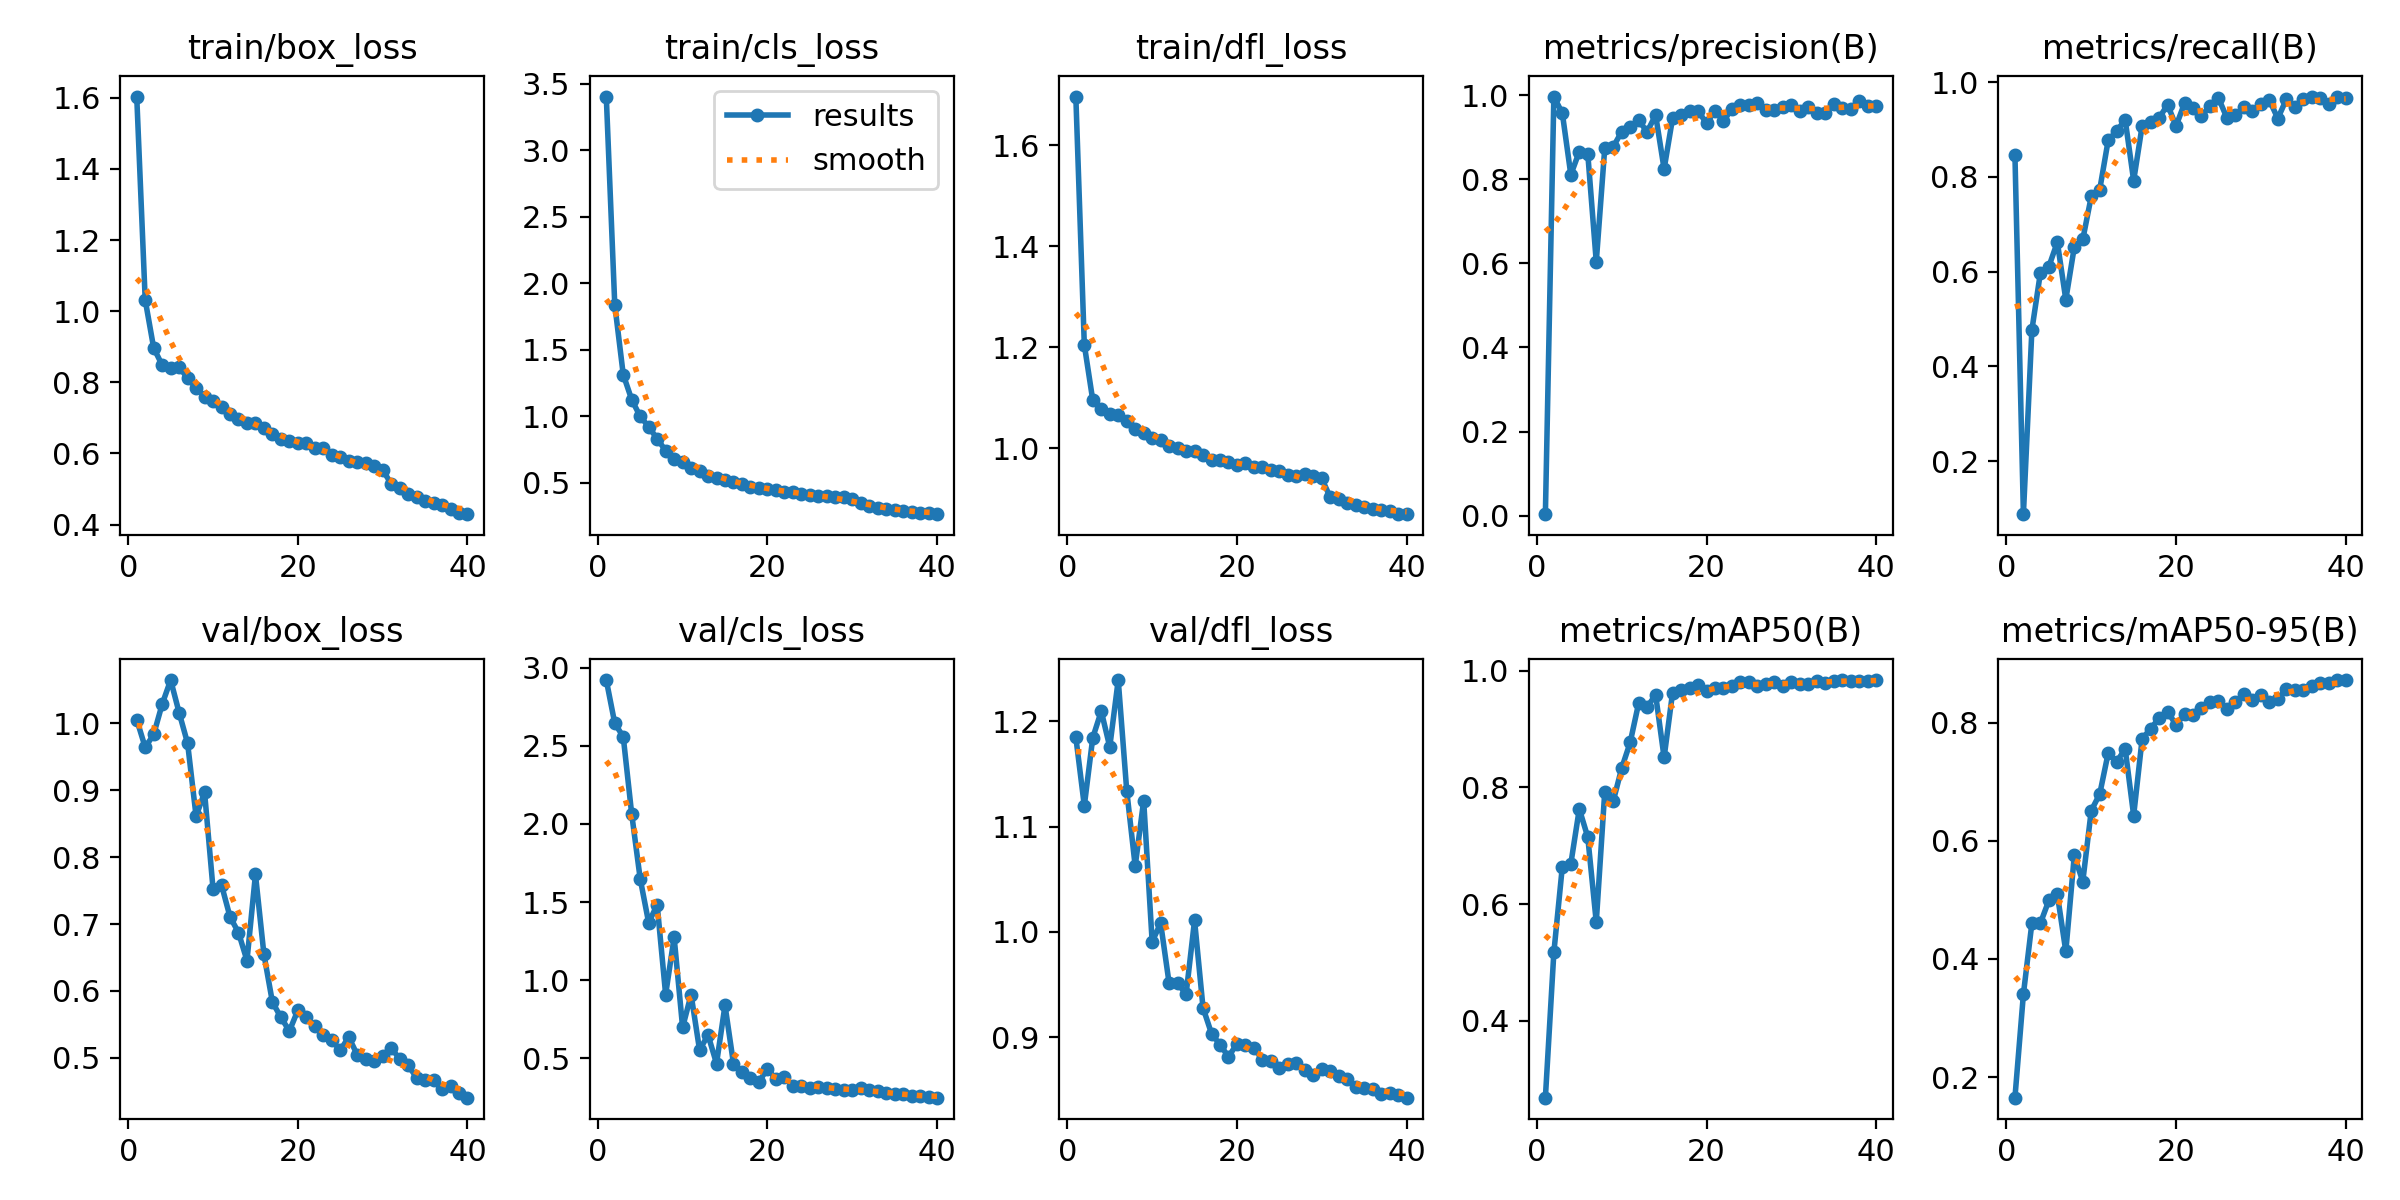

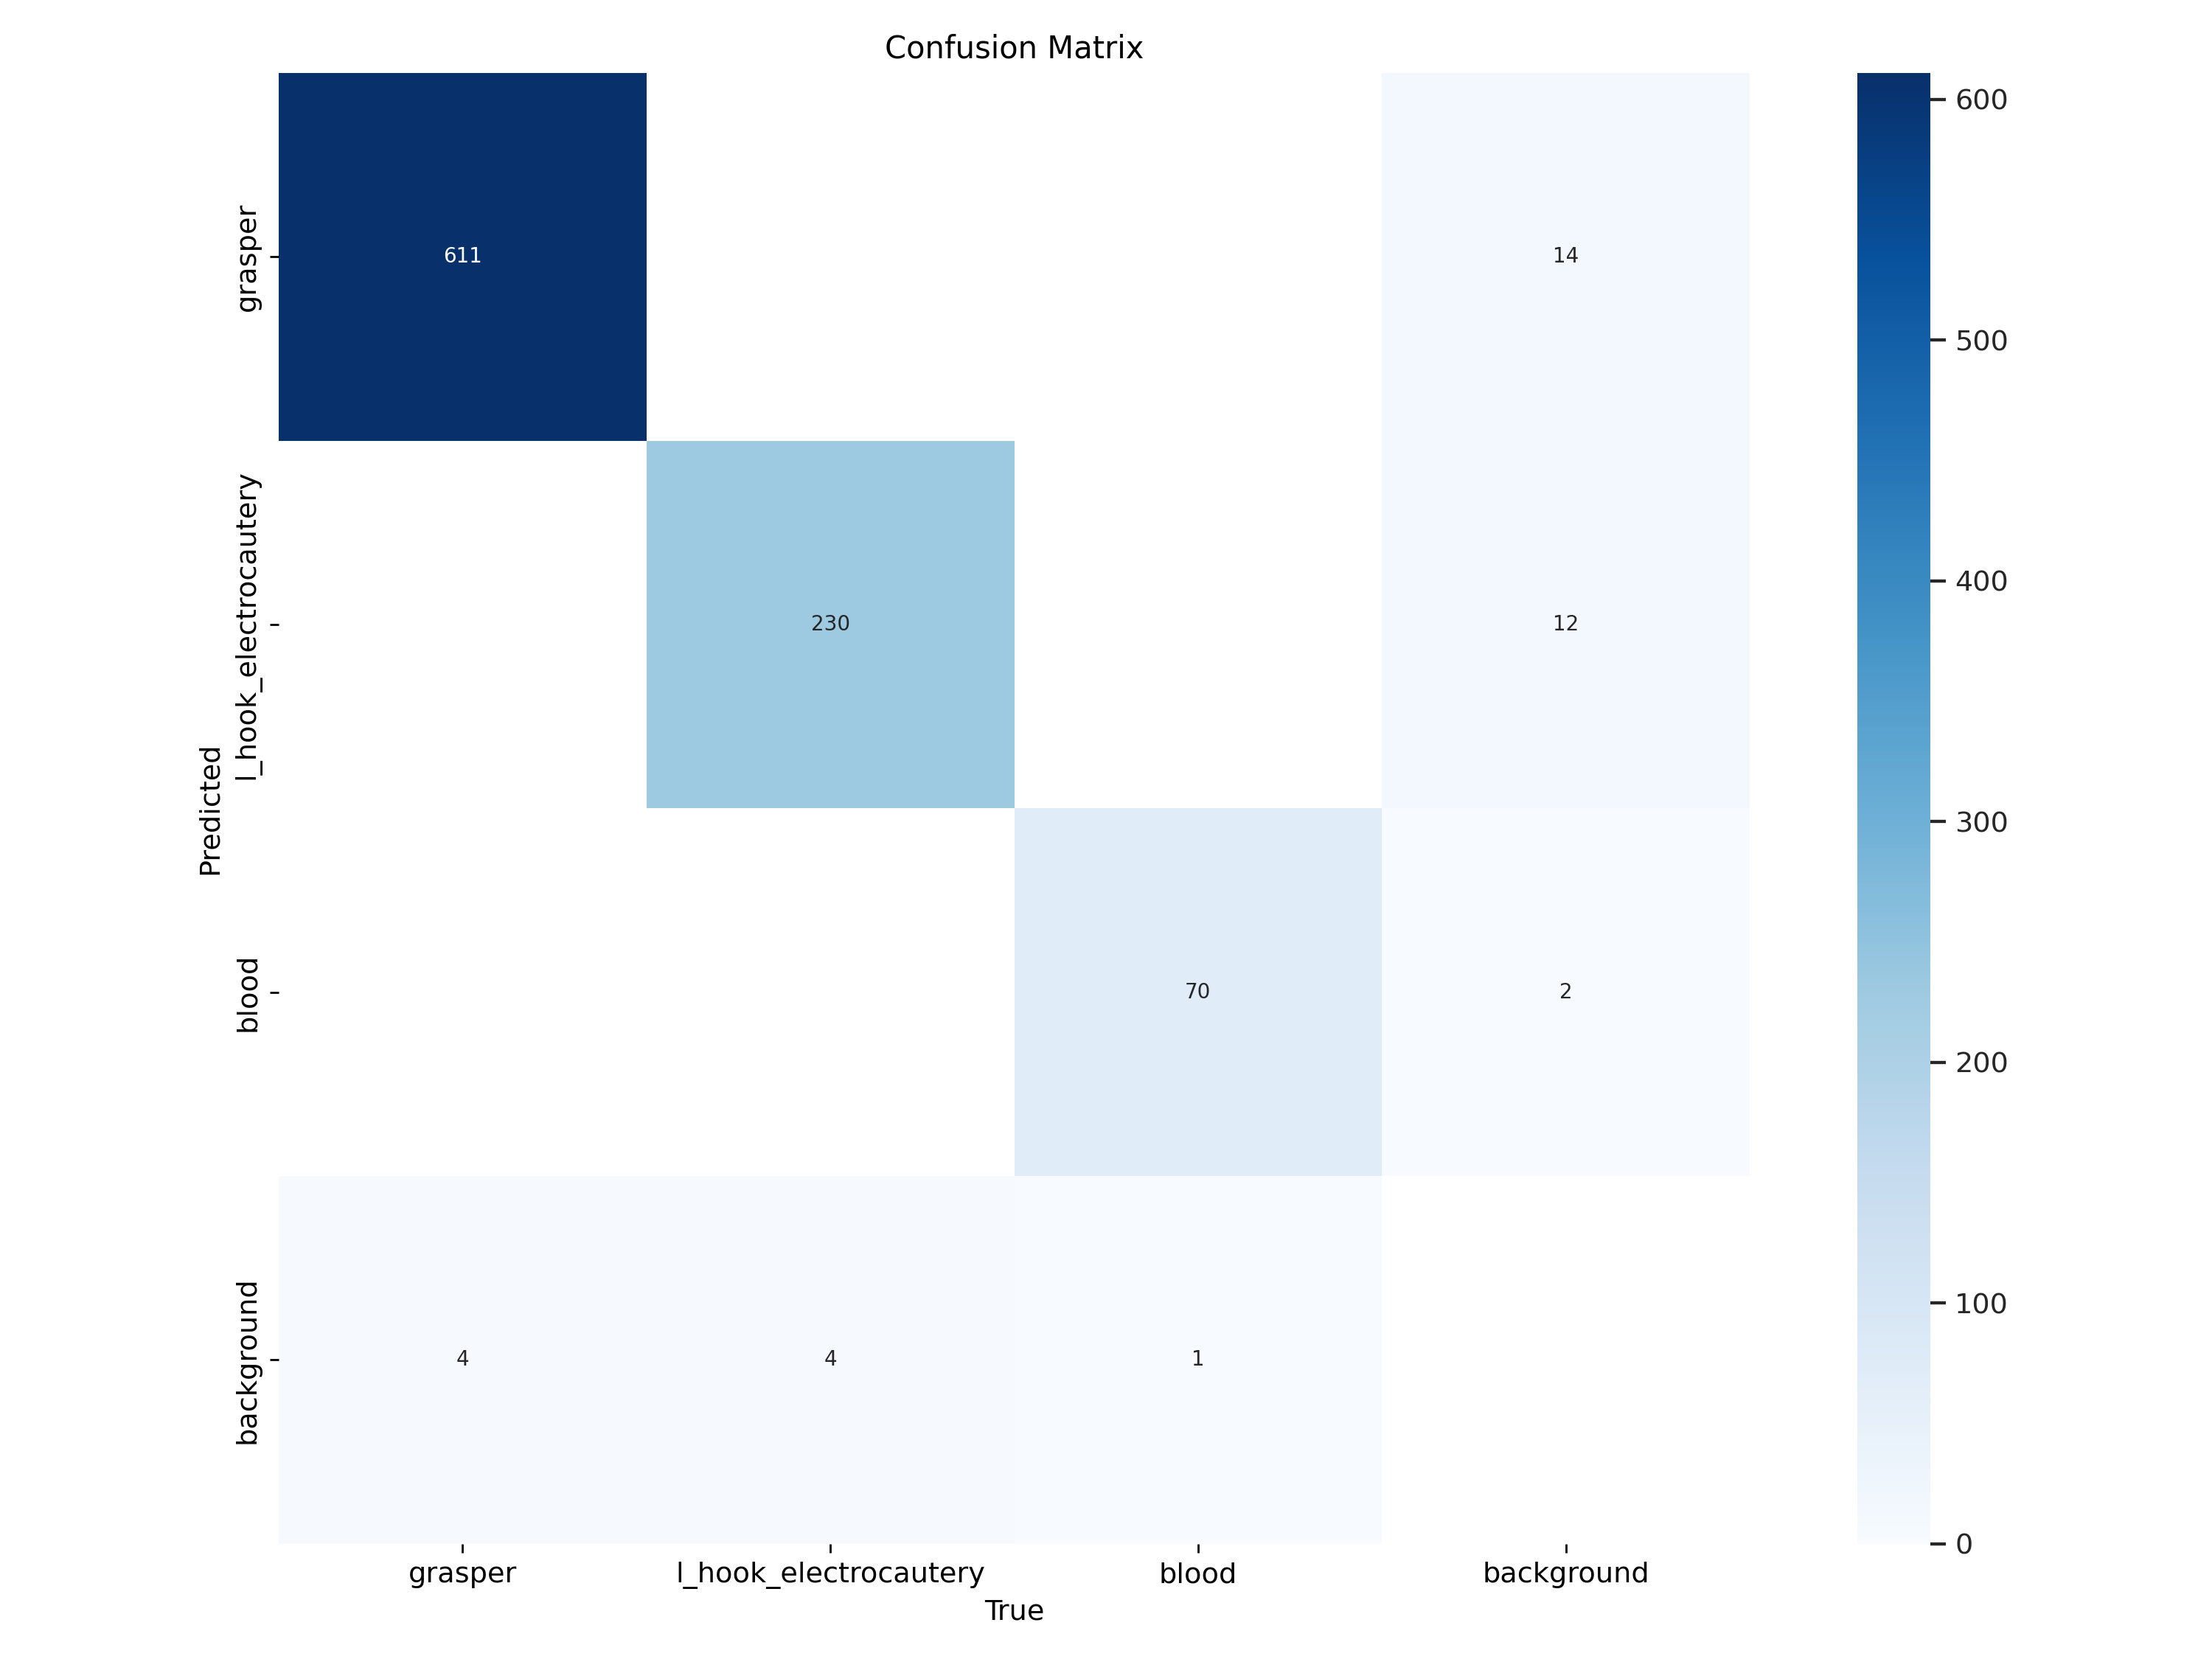

In [10]:
from IPython.display import Image as IPImage, display

display(IPImage(f'{RUNS_DIR}/{RUN_NAME}/results.png'))
display(IPImage(f'{RUNS_DIR}/{RUN_NAME}_test/confusion_matrix.png'))


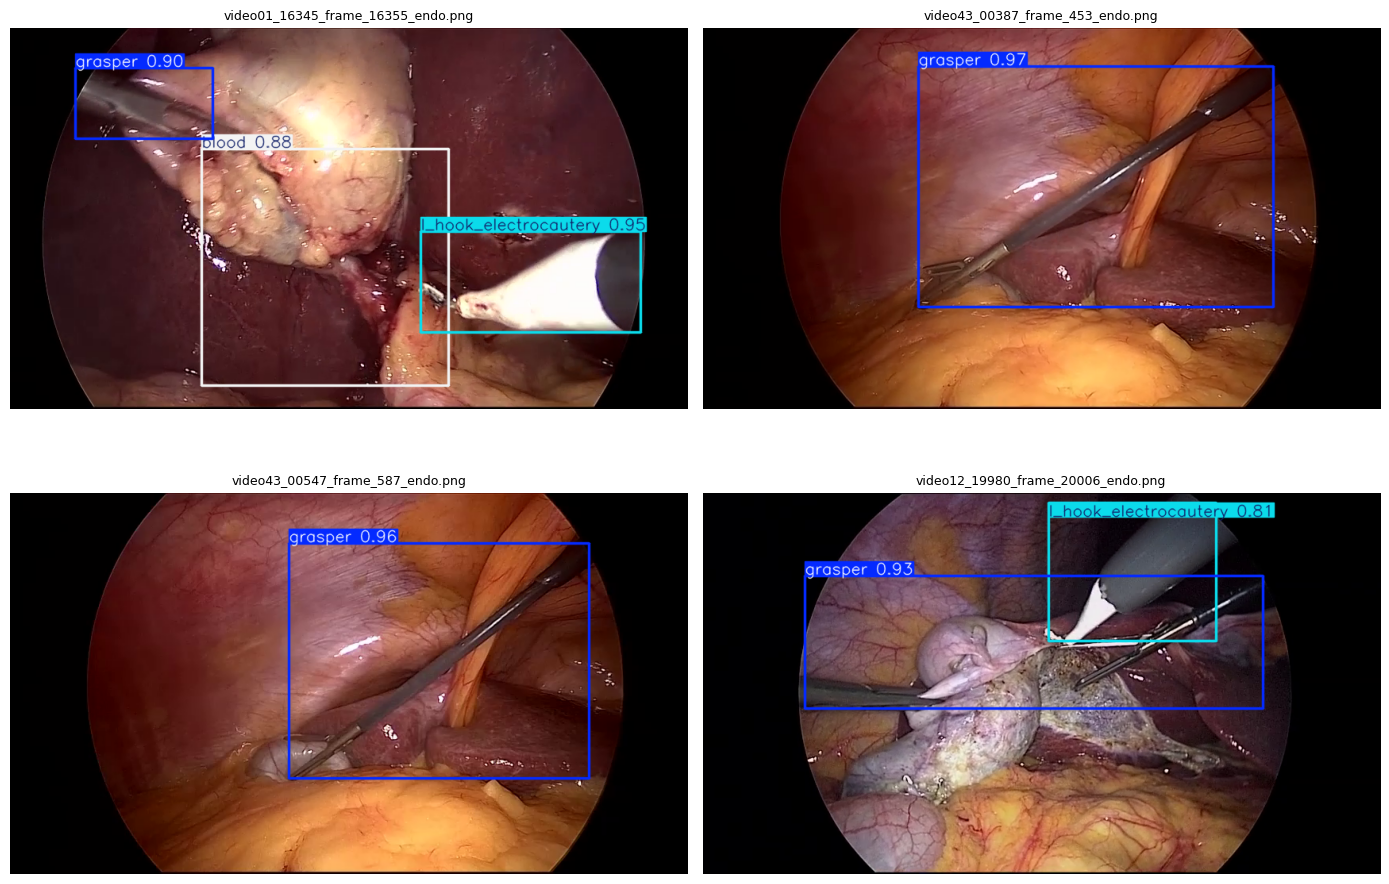

In [16]:
test_img_dir = os.path.join(DATASET_DIR, 'images', 'test')
test_samples = random.sample(os.listdir(test_img_dir), 4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, name in zip(axes.flat, test_samples):
    img_path = os.path.join(test_img_dir, name)
    pred = best_model(img_path, conf=0.25, verbose=False)[0]
    annotated = pred.plot()
    ax.imshow(annotated[..., ::-1])
    ax.set_title(name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


### 4.5 Validacao visual: video anotado com Blood detectado

Cura uma sequencia de frames do **test split** que contenham a classe `Blood` (id=2), roda o `best.pt` em cada frame, anota com bboxes detectadas e empacota em MP4. Esse video serve como evidencia visual no relatorio tecnico (Secao 7 - Validacao tecnica do modelo) de que o YOLO custom efetivamente detecta sangramento em frames de cirurgia laparoscopica.

O MP4 vai pro Drive em `yolo_runs/<RUN_NAME>/validation_blood_detected.mp4`.

In [17]:
import re
import subprocess
import tempfile
import shutil as _shutil
from collections import defaultdict
from pathlib import Path
import cv2

# 1) Encontrar frames do test split com label de Blood (classe 2)
test_lbl_dir = Path(DATASET_DIR) / 'labels' / 'test'
test_img_dir = Path(DATASET_DIR) / 'images' / 'test'

blood_frames = []
for lbl_file in sorted(test_lbl_dir.iterdir()):
    if not lbl_file.is_file():
        continue
    content = lbl_file.read_text()
    has_blood = any(line.strip().startswith('2 ') for line in content.split('\n'))
    if has_blood:
        blood_frames.append(lbl_file.stem + '.png')

print(f'Frames de test com Blood: {len(blood_frames)}')

if not blood_frames:
    print('AVISO: nenhum frame com classe Blood no test split.')
    print('Provavel causa: dataset convertido sem a classe 2. Refazer a 2.3 com 3 classes.')
else:
    # 2) Tentar agrupar por sequencia de video original
    # Tenta varios padroes porque o naming do CholecSeg8k pode variar
    def _seq_id(name):
        # Padrao 1: video_XX_YY_frame_NNN_endo.png
        m = re.match(r'(video_\d+_\d+)_', name)
        if m:
            return m.group(1)
        # Padrao 2: video_XX_frame_NNN_endo.png (sem sub-id)
        m = re.match(r'(video_\d+)_frame_', name)
        if m:
            return m.group(1)
        # Padrao 3: videoXX_videoXX_YY_... (sem underscore entre 'video' e numero)
        m = re.match(r'(video\d+(?:_\d+)?)', name)
        if m:
            return m.group(1)
        return None

    def _frame_num(name):
        m = re.search(r'frame_(\d+)', name)
        return int(m.group(1)) if m else -1

    by_seq = defaultdict(list)
    for name in blood_frames:
        s = _seq_id(name)
        if s:
            by_seq[s].append(name)

    # 3) Selecionar frames: prefere sequencia mais longa; fallback simples
    if by_seq:
        best_seq = max(by_seq.items(), key=lambda kv: len(kv[1]))
        seq_name, seq_frames = best_seq
        seq_frames = sorted(seq_frames, key=_frame_num)
        print(f'Sequencia escolhida: {seq_name} ({len(seq_frames)} frames com Blood)')
        sample = seq_frames[:30]
    else:
        # Nao conseguiu agrupar por sequencia: usa os primeiros frames sem agrupar
        # (video vai parecer 'cortado' entre cenas mas ainda mostra deteccoes)
        print(f'AVISO: regex de sequencia nao casou. Amostra de nomes:')
        for name in blood_frames[:3]:
            print(f'  {name}')
        print(f'Usando os primeiros 30 frames sem agrupar (video pode parecer descontinuo).')
        sample = sorted(blood_frames)[:30]

    print(f'Selecionados {len(sample)} frames pra video anotado')

    # 4) Rodar inferencia + anotar
    tmp_dir = Path(tempfile.mkdtemp(prefix='annot_'))
    try:
        for i, fname in enumerate(sample):
            img_path = test_img_dir / fname
            pred = best_model(str(img_path), conf=0.25, verbose=False)[0]
            annotated = pred.plot()  # numpy BGR com bboxes desenhadas
            cv2.imwrite(str(tmp_dir / f'frame_{i:04d}.png'), annotated)

        # 5) Empacotar em MP4 via ffmpeg @ 8 fps
        mp4_out = DRIVE_RUNS / RUN_NAME / 'validation_blood_detected.mp4'
        mp4_out.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(
            [
                'ffmpeg', '-y',
                '-framerate', '8',
                '-i', str(tmp_dir / 'frame_%04d.png'),
                '-c:v', 'libx264',
                '-pix_fmt', 'yuv420p',
                str(mp4_out),
            ],
            check=True,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        size_mb = mp4_out.stat().st_size / (1024 * 1024)
        print(f'\nVideo anotado salvo: {mp4_out}')
        print(f'Tamanho: {size_mb:.2f} MB ({len(sample)} frames @ 8 fps)')
        print('Use esse MP4 como evidencia visual no relatorio (Secao 7).')
    finally:
        _shutil.rmtree(tmp_dir, ignore_errors=True)


Frames de test com Blood: 71
Sequencia escolhida: video01_28660 (11 frames com Blood)
Selecionados 11 frames pra video anotado

Video anotado salvo: /content/drive/MyDrive/medica-ia/yolo_runs/surgical_instruments/validation_blood_detected.mp4
Tamanho: 0.32 MB (11 frames @ 8 fps)
Use esse MP4 como evidencia visual no relatorio (Secao 7).


## 5. Export

Copia `best.pt` + graficos para `EXPORT_DIR`. Baixar `best.pt` pela barra lateral do Colab (ou pelo Drive se `USE_DRIVE=True`), colocar em `models/yolov8n_surgical.pt` no repo e ajustar `YOLO_WEIGHTS_PATH` no `.env`.

In [18]:
# Os artefatos ja foram sincronizados pelo callback do treino.
# Esta celula confirma o que esta no Drive em yolo_runs/<RUN_NAME>/

drive_run = DRIVE_RUNS / RUN_NAME
print(f'Artefatos no Drive ({drive_run}):')
print()

key_files = [
    'weights/best.pt',
    'weights/last.pt',
    'results.png',
    'results.csv',
    f'../{RUN_NAME}_test/confusion_matrix.png',
    'val_batch0_pred.jpg',
]

for rel in key_files:
    f = drive_run / rel
    if f.exists():
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f'  OK   {rel:<40s} ({size_mb:.2f} MB)')
    else:
        print(f'  SKIP {rel:<40s} (nao gerado)')


Artefatos no Drive (/content/drive/MyDrive/medica-ia/yolo_runs/surgical_instruments):

  OK   weights/best.pt                          (5.94 MB)
  OK   weights/last.pt                          (5.94 MB)
  OK   results.png                              (0.25 MB)
  OK   results.csv                              (0.00 MB)
  SKIP ../surgical_instruments_test/confusion_matrix.png (nao gerado)
  OK   val_batch0_pred.jpg                      (0.35 MB)


## Fontes

- CholecSeg8k: Hong et al. (2020), [arXiv:2012.12463](https://arxiv.org/abs/2012.12463) (CC BY-NC-SA 4.0)
- Ultralytics YOLOv8: [docs.ultralytics.com](https://docs.ultralytics.com/)
- Repo do projeto: [github.com/joalissonborges94/medica-ia-multimodal](https://github.com/joalissonborges94/medica-ia-multimodal)